## Feature Selection from Algerian_forest_cleaned_dataset

In [113]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [114]:
df = pd.read_csv("Algerian_forest_fire_cleaned_dataset.csv")
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [115]:
df.columns

Index(['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes', 'Region'],
      dtype='str')

In [116]:
## We will select FWI as the dependent feature 

In [117]:
## Drop month day and year 
df.drop(['day','month','year'],axis=1,inplace=True)

In [118]:
df['Classes'].value_counts()

Classes
fire             131
not fire         101
fire               4
fire               2
not fire           2
not fire           1
not fire           1
not fire           1
Name: count, dtype: int64

In [119]:
## Encoding
df['Classes']=np.where(df['Classes'].str.contains("not fire"),0,1)

In [120]:
df.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,0,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,0,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,0,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,0,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,0,0


In [121]:
df['Classes'].value_counts() # we used encoding teqnique to make not fire and fire into  and 1 and 0

Classes
1    137
0    106
Name: count, dtype: int64

In [122]:
## Independent and dependent feature 
X = df.drop('FWI',axis=1)# will select all the features or we can say select all the column as feature except 'FWI'
Y = df['FWI']

In [123]:
X.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0,0


In [124]:
Y

0      0.5
1      0.4
2      0.1
3      0.0
4      0.5
      ... 
238    6.5
239    0.0
240    0.2
241    0.7
242    0.5
Name: FWI, Length: 243, dtype: float64

In [125]:
## Train Test Split 
from sklearn.model_selection import train_test_split 
X_train,Y_train,X_test,Y_test = train_test_split(X,Y,test_size=0.25,random_state=42)

In [126]:
X_train.shape ,X_test.shape

((182, 11), (182,))

In [127]:
## Feature selection based on correlation 
X_train.corr()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region
Temperature,1.000000,-0.656095,-0.305977,-0.317512,0.694768,0.498173,0.390684,0.629848,0.473609,0.542141,0.254549
RH,-0.656095,1.000000,0.225736,0.241656,-0.653023,-0.414601,-0.236078,-0.717804,-0.362317,-0.456876,-0.394665
Ws,-0.305977,0.225736,1.000000,0.251932,-0.190076,0.000379,0.096576,-0.023558,0.035633,-0.082570,-0.199969
Rain,-0.317512,0.241656,0.251932,1.000000,-0.545491,-0.289754,-0.302341,-0.345707,-0.300964,-0.369357,-0.059022
FFMC,0.694768,-0.653023,-0.190076,-0.545491,1.000000,0.620807,0.524101,0.750799,0.607210,0.781259,0.249514
DMC,0.498173,-0.414601,0.000379,-0.289754,0.620807,1.000000,0.868647,0.685656,0.983175,0.617273,0.212582
DC,0.390684,-0.236078,0.096576,-0.302341,0.524101,0.868647,1.000000,0.513701,0.942414,0.543581,-0.060838
ISI,0.629848,-0.717804,-0.023558,-0.345707,0.750799,0.685656,0.513701,1.000000,0.643818,0.742977,0.296441
BUI,0.473609,-0.362317,0.035633,-0.300964,0.607210,0.983175,0.942414,0.643818,1.000000,0.612239,0.114897
Classes,0.542141,-0.456876,-0.082570,-0.369357,0.781259,0.617273,0.543581,0.742977,0.612239,1.000000,0.188837


<Axes: >

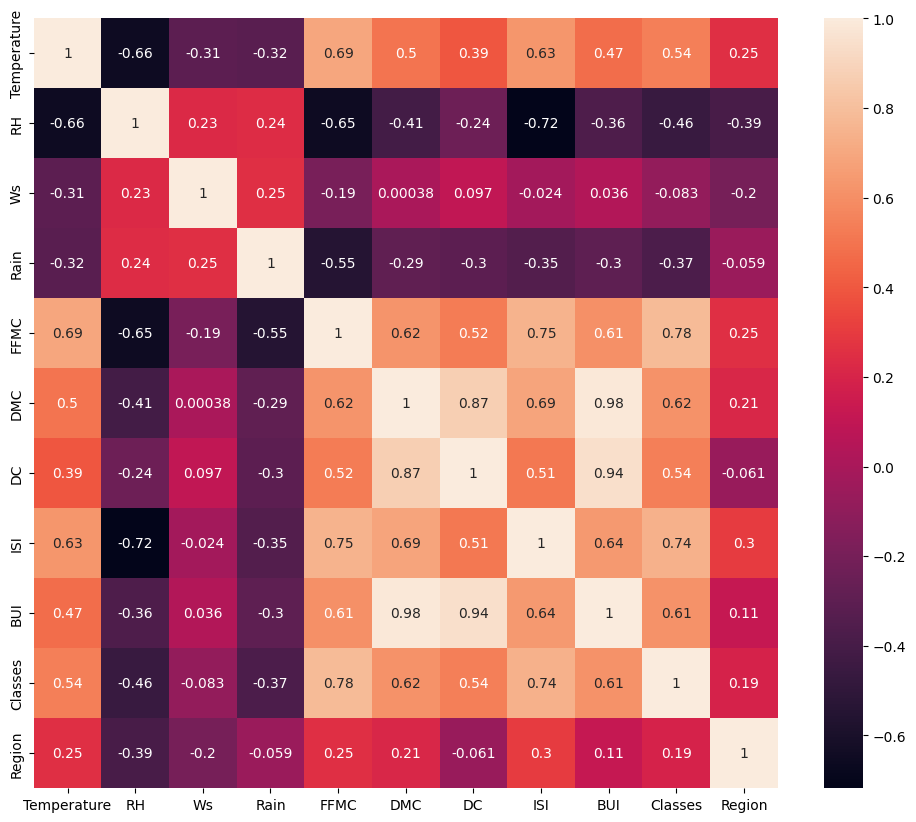

In [128]:
## Cheak for Multicollinearity
plt.figure(figsize=(12,10))
corr = X_train.corr()
sns.heatmap(corr,annot=True)

In [129]:
def correlation(dataset,threshold):
    col_corr = set()
    corr_matrix = dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i,j])>threshold:
               colname = corr_matrix.columns[i]
               col_corr.add(colname)
    return col_corr


In [130]:
#Threshold is setup by -- Domain Expert(Product manager) in big projects 
corr_feature=correlation(X_train,0.85)

In [131]:
## Dropping the feature if correlation is more then threshold
X_train.drop(corr_feature,axis=1,inplace=True)
# fix swapped outputs from earlier train_test_split
_temp = X_test
X_test = Y_train
Y_train = _temp

# now drop correlated features from test set (X_test is now a DataFrame)
X_test.drop(corr_feature, axis=1, inplace=True)
X_train.shape,X_test.shape

((182, 9), (61, 9))

In [147]:
# Feature Scaling or Standardization
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled= scaler.transform(X_test)


Text(0.5, 1.0, 'X_train after Scaling')

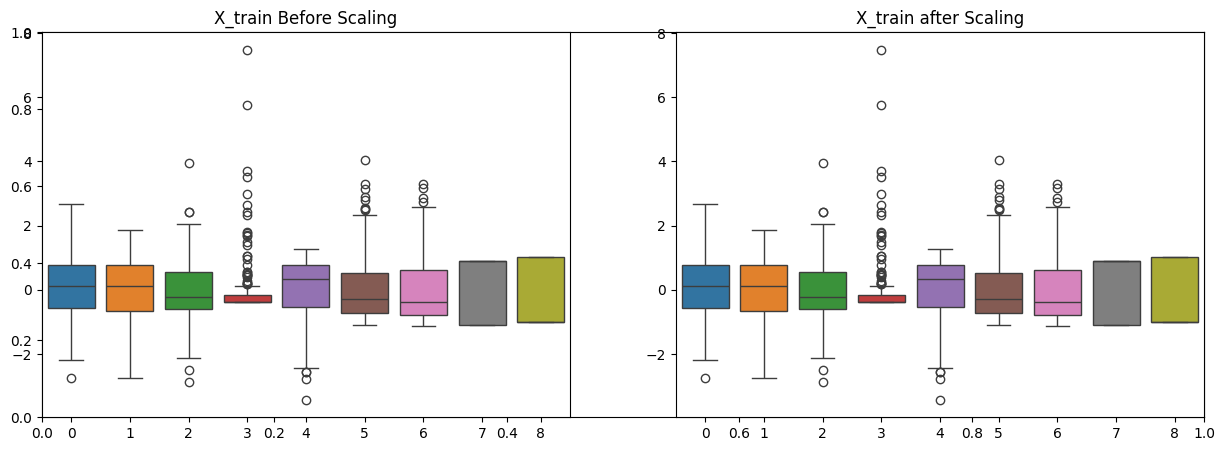

In [152]:
## Boxplot to understand the effect of standard scaler 
plt.subplots(figsize=(15,5))
plt.subplot(1,2,1)
sns.boxplot(data=X_train)
plt.title('X_train Before Scaling')
plt.subplot(1,2,2)
sns.boxplot(data=X_train_scaled)
plt.title('X_train after Scaling')

## Linear Regression Model

In [153]:
from sklearn.linear_model import LinearRegression

In [154]:
linear = LinearRegression()

In [155]:
linear.fit(X_train_scaled,Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](9,)","[-0.04,-0.17, 0.01,..., 4.84, 0.4 ,-0.39]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,7.156
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,9
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,9
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](9,)","[28.82,14.8 ,13.67,..., 7.68, 5.77, 4.49]"


In [168]:
y_pred = linear.predict(X_test_scaled)

In [169]:
## Evaluation metrics
from sklearn.metrics import mean_absolute_error, r2_score
mae = mean_absolute_error(Y_test,y_pred)
r2score= r2_score(Y_test,y_pred)

In [170]:
print(mae)
print(r2score)

0.5468236465249982
0.9847657384266951


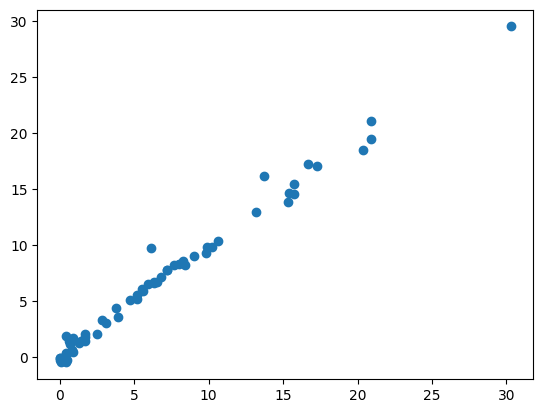

In [171]:
plt.scatter(Y_test,y_pred)

## Lasso Regression Model

Mean absolute error:  113.31759949144084 %
R2_score(test data):  94.92020263112389 %


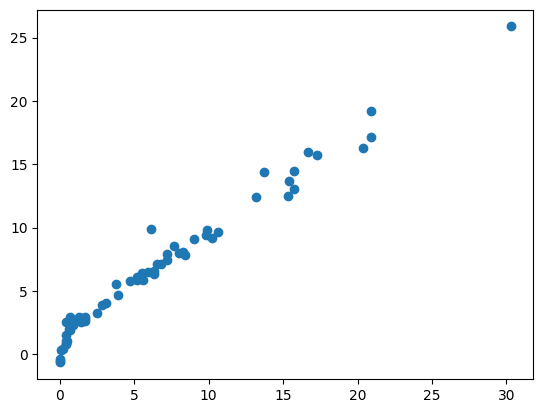

In [183]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error, r2_score
lasso = Lasso()
lasso.fit(X_train_scaled,Y_train)
y_pred = lasso.predict(X_test_scaled)
## Evaluation metrics
mae = mean_absolute_error(Y_test,y_pred)
test_r2score= r2_score(Y_test,y_pred)
print("Mean absolute error: ",mae*100,"%")
print("R2_score(test data): ",r2score*100,"%")
plt.scatter(Y_test,y_pred)

## Ridge Regression Model 

Mean absolute error:  56.423053401056954 %
R2_score(test data):  94.92020263112389 %


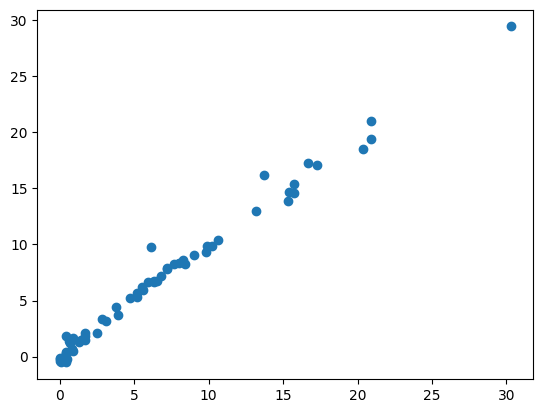

In [184]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score
ridge = Ridge()
ridge.fit(X_train_scaled,Y_train)
y_pred = ridge.predict(X_test_scaled)
## Evaluation metrics
mae = mean_absolute_error(Y_test,y_pred)
test_r2score= r2_score(Y_test,y_pred)
print("Mean absolute error: ",mae*100,"%")
print("R2_score(test data): ",r2score*100,"%")
plt.scatter(Y_test,y_pred)

## ElasticNet Model

Mean absolute error:  188.22353634895995 %
R2_score(test data):  94.92020263112389 %


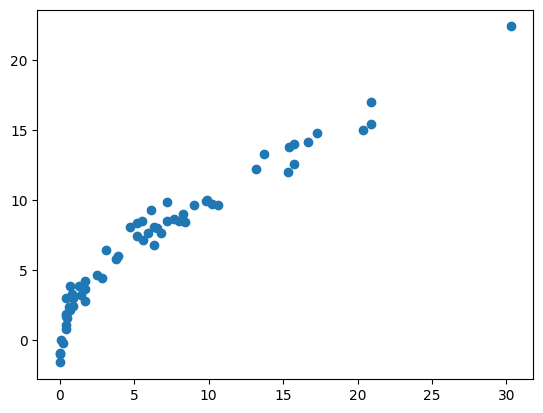

In [185]:
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error, r2_score
elastic = ElasticNet()
elastic.fit(X_train_scaled,Y_train)
y_pred = elastic.predict(X_test_scaled)
## Evaluation metrics
mae = mean_absolute_error(Y_test,y_pred)
test_r2score= r2_score(Y_test,y_pred)
print("Mean absolute error: ",mae*100,"%")
print("R2_score(test data): ",r2score*100,"%")
plt.scatter(Y_test,y_pred)